# **importing libraries **

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
df=pd.read_csv('/content/drive/MyDrive/spam.csv',encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
#data cleaning
#EDA (exporatory data analysis)
#text processing
#Model building
#evaluation
#improvements

# ***1. DATA CLEANING***

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
#dropping last three columns as they are having very low non null values
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(5)

,v1,v2
4624,ham,I'm on the bus. Love you
1816,ham,Are you going to write ccna exam this week??
4104,ham,Jus finish my lunch on my way home lor... I to...
2250,ham,I am getting threats from your sales executive...
3408,ham,Whats that coming over the hill..... Is it a m...


In [11]:
#renaming v1 and v2
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1793,ham,You bad girl. I can still remember them
4825,ham,"Haha, just what I was thinkin"
4983,spam,goldviking (29/M) is inviting you to be his fr...
2522,ham,Dunno lei... I might b eatin wif my frens... I...
4933,ham,Hey do you want anything to buy:)


In [12]:
#check for null values
df.isnull().sum()

,0
target,0
text,0


In [13]:
#check for duplicated values
df.duplicated().sum()

np.int64(403)

In [14]:
df.drop_duplicates(inplace=True)
df.sample(5)


,target,text
1481,ham,"I'm a guy, browsin is compulsory"
4434,spam,Don't b floppy... b snappy & happy! Only gay c...
4266,ham,SORRY IM STIL FUCKED AFTER LAST NITE WENT TOBE...
4674,spam,"Hi babe its Chloe, how r u? I was smashed on s..."
151,ham,Yup i thk cine is better cos no need 2 go down...


In [15]:
df.shape

(5169, 2)

In [16]:
#assigning 0 to ham and 1 to spam
df['target']=df['target'].map({'ham':0,'spam':1})
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# **EDA (exporatory data analysis)**

In [17]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
#check for data balance
df['target'].value_counts()
#data is imbalanced

,count
target,
0,4516
1,653


In [19]:
import nltk
nltk.download('punkt_tab')
df['num_chars']=df['text'].apply(len)
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,target,text,num_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
#number of words

df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,num_chars,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [21]:

#number of sentences
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_chars,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [22]:
df.describe()

,target,num_chars,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [23]:
#description of ham data
df[df['target']==0][['num_chars','num_words','num_sentences']].describe()

,num_chars,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
#description of spam data
df[df['target']==1][['num_chars','num_words','num_sentences']].describe()

,num_chars,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [25]:
df.sample(5)

,target,text,num_chars,num_words,num_sentences
1649,0,ITS A LAPTOP TAKE IT WITH YOU.,30,8,1
1199,0,NEFT Transaction with reference number &lt;#&...,164,53,2
3413,0,No pic. Please re-send.,23,6,2
1551,0,In e msg jus now. U said thanks for gift.,41,12,2
1247,0,Horrible gal. Me in sch doing some stuff. How ...,60,16,3


<Axes: xlabel='num_chars', ylabel='Count'>

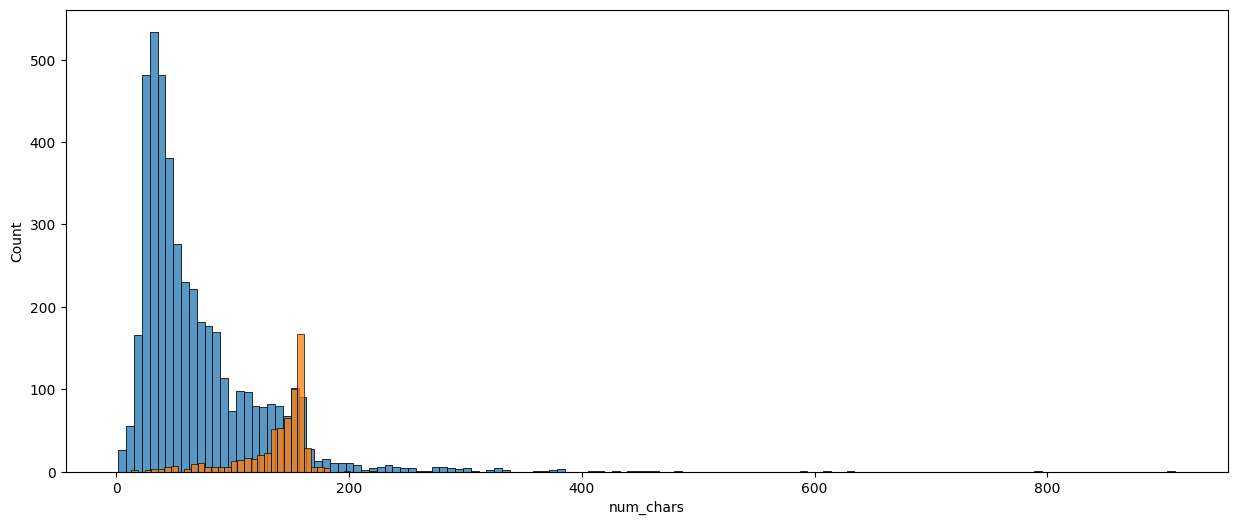

In [26]:

plt.figure(figsize=(15,6))
sns.histplot(df[df['target']==0]['num_chars'])
sns.histplot(df[df['target']==1]['num_chars'])

<Axes: xlabel='num_words', ylabel='Count'>

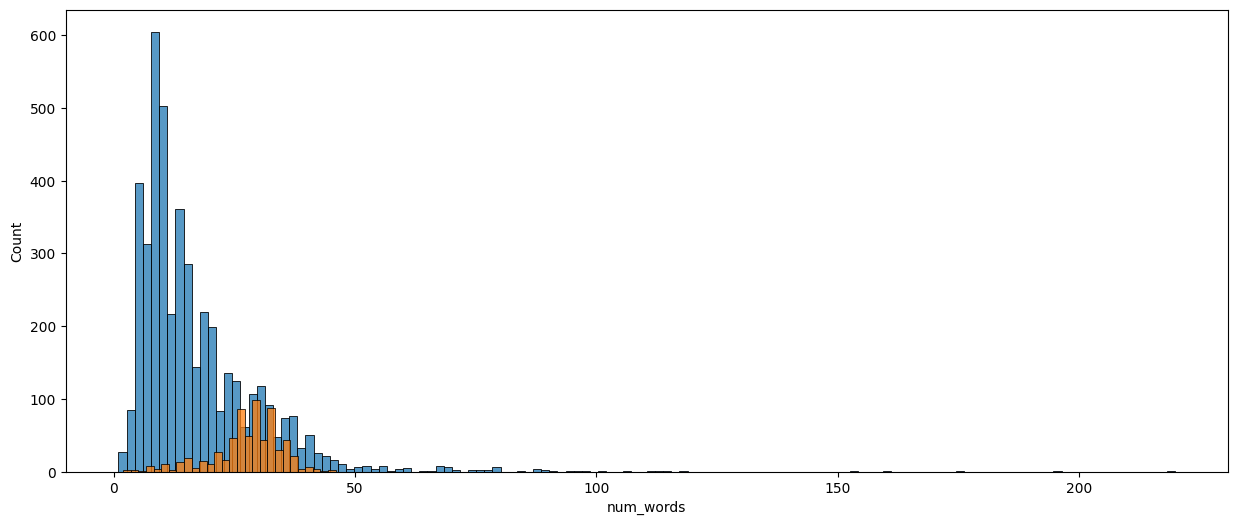

In [27]:
plt.figure(figsize=(15,6))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'])

<Axes: xlabel='num_sentences', ylabel='Count'>

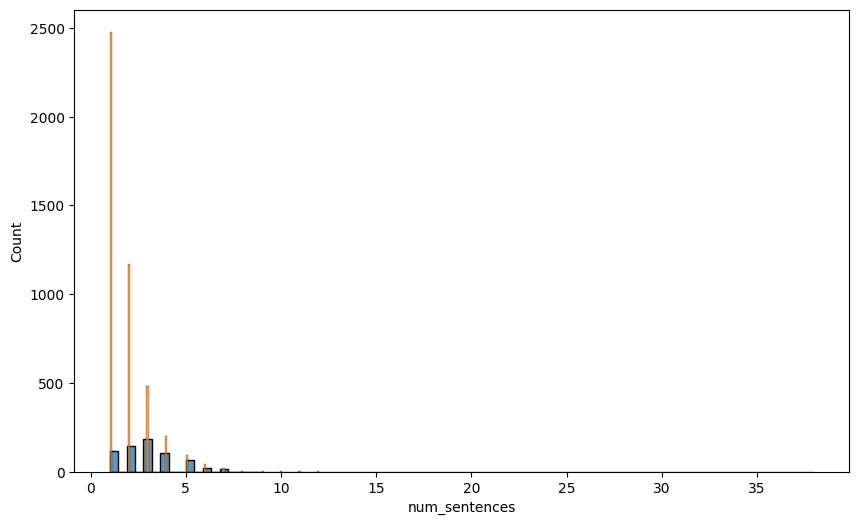

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target']==1]['num_sentences'])
sns.histplot(df[df['target']==0]['num_sentences'])

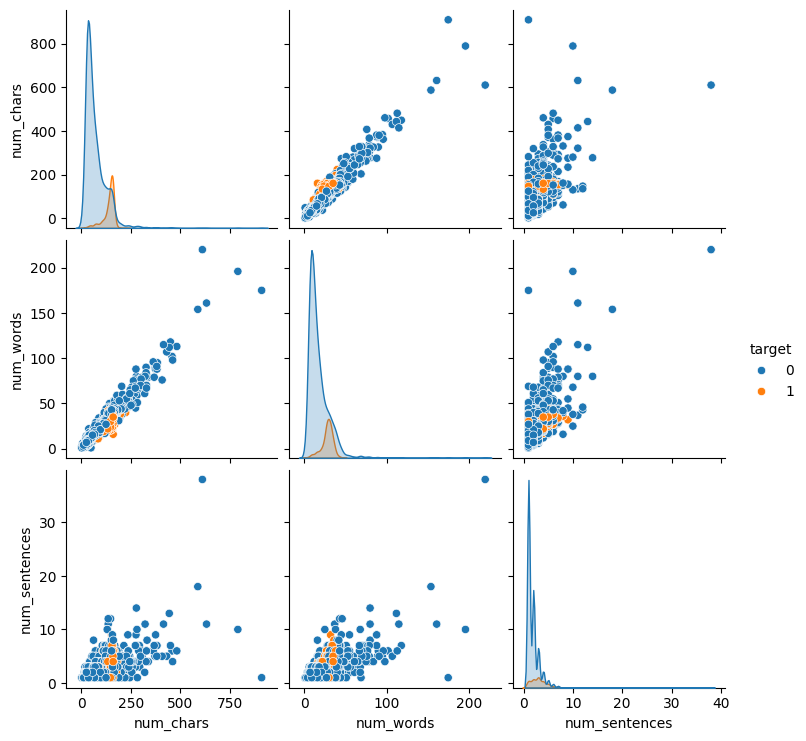

In [29]:
sns.pairplot(df,hue='target')

In [30]:
correlation=df[['target','num_chars','num_words','num_sentences']].corr()
correlation

,target,num_chars,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_chars,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

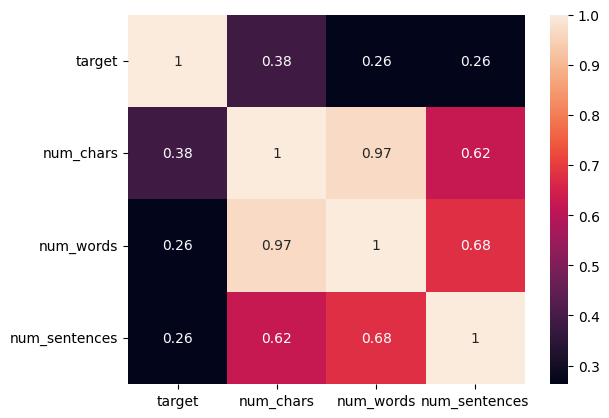

In [31]:
sns.heatmap(correlation,annot=True)

In [32]:
df.head()

,target,text,num_chars,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


# **DATA  PREPROCESSING**

In [33]:

#LOWERCASE
#TOKENIZATION
#REMOVING SPECIAL CHARS
#REMOVING STOPWORDS AND PUNCTUATIONS
#STEMMING

def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)
  text.clear()
  for i in y:
    if i not in stopwords.words('english') and i not in string.punctuation:
      text.append(i)
  y.clear()
  ps=PorterStemmer()
  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)



In [34]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [35]:
transform_text('ashish got have are you 99% dance dancing love loving dancer')

'ashish got 99 danc danc love love dancer'

In [36]:


df['transformed_text']=df['text'].apply(transform_text)
df.head()

,target,text,num_chars,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [37]:

from wordcloud import WordCloud


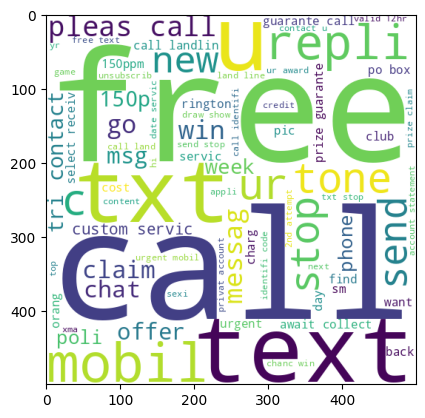

In [38]:




wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

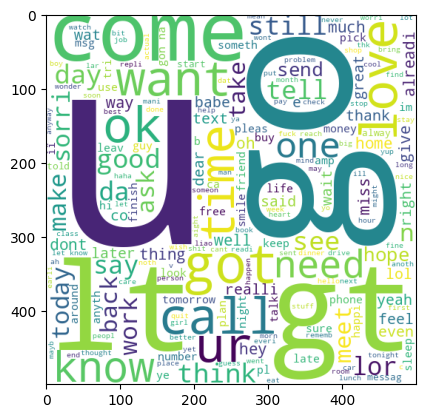

In [39]:



ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)


In [40]:


from sklearn.feature_extraction.text import TfidfVectorizer
tfdif=TfidfVectorizer(max_features=4500)
x=tfdif.fit_transform(df['transformed_text']).toarray()
x,x.shape


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (5169, 4500))

In [41]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [42]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [43]:
gnb=GaussianNB()
dtc=DecisionTreeClassifier(max_depth=5)
knn=KNeighborsClassifier(n_neighbors=10)
lr=LogisticRegression()
svc=SVC()

In [44]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists for metrics
accuracy = [[], [], [], [], []]
precision = [[], [], [], [], []]
recall = [[], [], [], [], []]
f1 = [[], [], [], [], []]

# Sum confusion matrices for 5 classifiers (assumed binary classification)
sum_cm = [np.zeros((2, 2), dtype=int) for _ in range(5)]

for train_index, test_index in kfold.split(x):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train models
    gnb.fit(X_train, y_train)
    dtc.fit(X_train, y_train)
    knn.fit(X_train, y_train)
    lr.fit(X_train, y_train)
    svc.fit(X_train, y_train)

    # Predict
    y_preds = [
        gnb.predict(X_test),
        dtc.predict(X_test),
        knn.predict(X_test),
        lr.predict(X_test),
        svc.predict(X_test)
    ]

    # Loop through each classifier's predictions
    for i, y_pred in enumerate(y_preds):
        accuracy[i].append(accuracy_score(y_test, y_pred))
        precision[i].append(precision_score(y_test, y_pred))
        recall[i].append(recall_score(y_test, y_pred))
        f1[i].append(f1_score(y_test, y_pred))
        sum_cm[i] += confusion_matrix(y_test, y_pred, labels=[0, 1])  # Assuming binary classes 0 and 1

# To print final summed confusion matrices:
for i, cm in enumerate(sum_cm):
    print(f"\nClassifier {i+1} Confusion Matrix (summed over 5 folds):\n{cm}")



Classifier 1 Confusion Matrix (summed over 5 folds):
[[3914  602]
 [  99  554]]

Classifier 2 Confusion Matrix (summed over 5 folds):
[[4437   79]
 [ 255  398]]

Classifier 3 Confusion Matrix (summed over 5 folds):
[[4516    0]
 [ 574   79]]

Classifier 4 Confusion Matrix (summed over 5 folds):
[[4505   11]
 [ 216  437]]

Classifier 5 Confusion Matrix (summed over 5 folds):
[[4511    5]
 [ 141  512]]


In [45]:
print("Average Accuracy:")
print("GaussianNB     :", np.mean(accuracy[0]))
print("Decision Tree  :", np.mean(accuracy[1]))
print("KNN            :", np.mean(accuracy[2]))
print("Logistic       :", np.mean(accuracy[3]))
print("SVC            :", np.mean(accuracy[4]))

print("\nAverage Precision:")
print("GaussianNB     :", np.mean(precision[0]))
print("Decision Tree  :", np.mean(precision[1]))
print("KNN            :", np.mean(precision[2]))
print("Logistic       :", np.mean(precision[3]))
print("SVC            :", np.mean(precision[4]))

print("\nAverage Recall:")
print("GaussianNB     :", np.mean(recall[0]))
print("Decision Tree  :", np.mean(recall[1]))
print("KNN            :", np.mean(recall[2]))
print("Logistic       :", np.mean(recall[3]))
print("SVC            :", np.mean(recall[4]))

print("\nAverage F1-Score:")
print("GaussianNB     :", np.mean(f1[0]))
print("Decision Tree  :", np.mean(f1[1]))
print("KNN            :", np.mean(f1[2]))
print("Logistic       :", np.mean(f1[3]))
print("SVC            :", np.mean(f1[4]))


Average Accuracy:
GaussianNB     : 0.8643808478806727
Decision Tree  : 0.9353834112582644
KNN            : 0.8889559432349488
Logistic       : 0.9560846045676431
SVC            : 0.971754724647559

Average Precision:
GaussianNB     : 0.480044102747482
Decision Tree  : 0.8328762500369926
KNN            : 1.0
Logistic       : 0.9773793668276427
SVC            : 0.9905710080895689

Average Recall:
GaussianNB     : 0.8487033623718643
Decision Tree  : 0.607061706168525
KNN            : 0.12144423779685401
Logistic       : 0.6673063580119956
SVC            : 0.7829015837044035

Average F1-Score:
GaussianNB     : 0.6121749918934276
Decision Tree  : 0.7013094751763258
KNN            : 0.21520375360567612
Logistic       : 0.7923671150921584
SVC            : 0.8743757353057058


In [46]:
"""Average Accuracy:
GaussianNB     : 0.8643808478806727
Decision Tree  : 0.936350529246659          without max features
KNN            : 0.882184806604489
Logistic       : 0.950667807609992
SVC            : 0.9684661489979609

Average Precision:
GaussianNB     : 0.480044102747482
Decision Tree  : 0.8383360578135693
KNN            : 1.0
Logistic       : 0.975835222112214
SVC            : 0.9899526847421584

Average Recall:
GaussianNB     : 0.8487033623718643
Decision Tree  : 0.6120110873679915
KNN            : 0.06732290655924014
Logistic       : 0.6244068021901066
SVC            : 0.7574012274066981

Average F1-Score:
GaussianNB     : 0.6121749918934276
Decision Tree  : 0.7060313602212422
KNN            : 0.12590512028682976
Logistic       : 0.7607997081085861
SVC            : 0.8581114243813619"""

'Average Accuracy:\nGaussianNB     : 0.8643808478806727\nDecision Tree  : 0.936350529246659          without max features\nKNN            : 0.882184806604489\nLogistic       : 0.950667807609992\nSVC            : 0.9684661489979609\n\nAverage Precision:\nGaussianNB     : 0.480044102747482\nDecision Tree  : 0.8383360578135693\nKNN            : 1.0\nLogistic       : 0.975835222112214\nSVC            : 0.9899526847421584\n\nAverage Recall:\nGaussianNB     : 0.8487033623718643\nDecision Tree  : 0.6120110873679915\nKNN            : 0.06732290655924014\nLogistic       : 0.6244068021901066\nSVC            : 0.7574012274066981\n\nAverage F1-Score:\nGaussianNB     : 0.6121749918934276\nDecision Tree  : 0.7060313602212422\nKNN            : 0.12590512028682976\nLogistic       : 0.7607997081085861\nSVC            : 0.8581114243813619'

In [47]:
"""Average Accuracy:
GaussianNB     : 0.8643808478806727
Decision Tree  : 0.9322880719618171
KNN            : 0.887795214404347
Logistic       : 0.9553109101769273
SVC            : 0.9711742666099938
                                                    max features=5000
Average Precision:
GaussianNB     : 0.480044102747482
Decision Tree  : 0.8006613453901483
KNN            : 1.0
Logistic       : 0.9771275416852545
SVC            : 0.9905186916224192

Average Recall:
GaussianNB     : 0.8487033623718643
Decision Tree  : 0.6166226567560616
KNN            : 0.11212735689530955
Logistic       : 0.6614691747742378
SVC            : 0.7782861540929225

Average F1-Score:
GaussianNB     : 0.6121749918934276
Decision Tree  : 0.6953049349323056
KNN            : 0.20075373961154605
Logistic       : 0.7882731210909074
SVC            : 0.8714397898925268"""

'Average Accuracy:\nGaussianNB     : 0.8643808478806727\nDecision Tree  : 0.9322880719618171\nKNN            : 0.887795214404347\nLogistic       : 0.9553109101769273\nSVC            : 0.9711742666099938\n                                                    max features=5000\nAverage Precision:\nGaussianNB     : 0.480044102747482\nDecision Tree  : 0.8006613453901483\nKNN            : 1.0\nLogistic       : 0.9771275416852545\nSVC            : 0.9905186916224192\n\nAverage Recall:\nGaussianNB     : 0.8487033623718643\nDecision Tree  : 0.6166226567560616\nKNN            : 0.11212735689530955\nLogistic       : 0.6614691747742378\nSVC            : 0.7782861540929225\n\nAverage F1-Score:\nGaussianNB     : 0.6121749918934276\nDecision Tree  : 0.6953049349323056\nKNN            : 0.20075373961154605\nLogistic       : 0.7882731210909074\nSVC            : 0.8714397898925268'

In [48]:
"""Average Accuracy:
GaussianNB     : 0.8643808478806727
Decision Tree  : 0.9342223079386063
KNN            : 0.8895362140279856
Logistic       : 0.9553107229323989
SVC            : 0.972141759087445
                                              max feature =4000
Average Precision:
GaussianNB     : 0.480044102747482
Decision Tree  : 0.828590640450375
KNN            : 1.0
Logistic       : 0.9750937506620809
SVC            : 0.9887175930865251

Average Recall:
GaussianNB     : 0.8487033623718643
Decision Tree  : 0.6004809776695392
KNN            : 0.1260724760609641
Logistic       : 0.6625183937544913
SVC            : 0.7874940551571291

Average F1-Score:
GaussianNB     : 0.6121749918934276
Decision Tree  : 0.6954543022538278
KNN            : 0.2227050387736756
Logistic       : 0.7881298219594844
SVC            : 0.8765342894212503"""

'Average Accuracy:\nGaussianNB     : 0.8643808478806727\nDecision Tree  : 0.9342223079386063\nKNN            : 0.8895362140279856\nLogistic       : 0.9553107229323989\nSVC            : 0.972141759087445\n                                              max feature =4000\nAverage Precision:\nGaussianNB     : 0.480044102747482\nDecision Tree  : 0.828590640450375\nKNN            : 1.0\nLogistic       : 0.9750937506620809\nSVC            : 0.9887175930865251\n\nAverage Recall:\nGaussianNB     : 0.8487033623718643\nDecision Tree  : 0.6004809776695392\nKNN            : 0.1260724760609641\nLogistic       : 0.6625183937544913\nSVC            : 0.7874940551571291\n\nAverage F1-Score:\nGaussianNB     : 0.6121749918934276\nDecision Tree  : 0.6954543022538278\nKNN            : 0.2227050387736756\nLogistic       : 0.7881298219594844\nSVC            : 0.8765342894212503'

In [49]:
"""Average Accuracy:
GaussianNB     : 0.8643808478806727
Decision Tree  : 0.9340290715854556
KNN            : 0.8889559432349488
Logistic       : 0.9560846045676431
SVC            : 0.971754724647559
                                          max feature 4500
Average Precision:
GaussianNB     : 0.480044102747482
Decision Tree  : 0.8254812441883088
KNN            : 1.0
Logistic       : 0.9773793668276427
SVC            : 0.9905710080895689

Average Recall:
GaussianNB     : 0.8487033623718643
Decision Tree  : 0.602334636156004
KNN            : 0.12144423779685401
Logistic       : 0.6673063580119956
SVC            : 0.7829015837044035

Average F1-Score:
GaussianNB     : 0.6121749918934276
Decision Tree  : 0.695329161824737
KNN            : 0.21520375360567612
Logistic       : 0.7923671150921584
SVC            : 0.8743757353057058"""

'Average Accuracy:\nGaussianNB     : 0.8643808478806727\nDecision Tree  : 0.9340290715854556\nKNN            : 0.8889559432349488\nLogistic       : 0.9560846045676431\nSVC            : 0.971754724647559\n                                          max feature 4500\nAverage Precision:\nGaussianNB     : 0.480044102747482\nDecision Tree  : 0.8254812441883088\nKNN            : 1.0\nLogistic       : 0.9773793668276427\nSVC            : 0.9905710080895689\n\nAverage Recall:\nGaussianNB     : 0.8487033623718643\nDecision Tree  : 0.602334636156004\nKNN            : 0.12144423779685401\nLogistic       : 0.6673063580119956\nSVC            : 0.7829015837044035\n\nAverage F1-Score:\nGaussianNB     : 0.6121749918934276\nDecision Tree  : 0.695329161824737\nKNN            : 0.21520375360567612\nLogistic       : 0.7923671150921584\nSVC            : 0.8743757353057058'

In [50]:
"""Average Accuracy:
GaussianNB     : 0.8643808478806727
Decision Tree  : 0.9342224951831346
KNN            : 0.8881822488442331
Logistic       : 0.956084604567643
SVC            : 0.9715611138053518
                                        max features = 4700
Average Precision:
GaussianNB     : 0.480044102747482
Decision Tree  : 0.8138821550196516
KNN            : 1.0
Logistic       : 0.9773769777093528
SVC            : 0.9905710080895689

Average Recall:
GaussianNB     : 0.8487033623718643
Decision Tree  : 0.6200542688274939
KNN            : 0.11521606894953887
Logistic       : 0.6672582724196412
SVC            : 0.7811921819950018

Average F1-Score:
GaussianNB     : 0.6121749918934276
Decision Tree  : 0.7028201220938811
KNN            : 0.20558917918241013
Logistic       : 0.7923392819035425
SVC            : 0.8732566535266526"""

'Average Accuracy:\nGaussianNB     : 0.8643808478806727\nDecision Tree  : 0.9342224951831346\nKNN            : 0.8881822488442331\nLogistic       : 0.956084604567643\nSVC            : 0.9715611138053518\n                                        max features = 4700\nAverage Precision:\nGaussianNB     : 0.480044102747482\nDecision Tree  : 0.8138821550196516\nKNN            : 1.0\nLogistic       : 0.9773769777093528\nSVC            : 0.9905710080895689\n\nAverage Recall:\nGaussianNB     : 0.8487033623718643\nDecision Tree  : 0.6200542688274939\nKNN            : 0.11521606894953887\nLogistic       : 0.6672582724196412\nSVC            : 0.7811921819950018\n\nAverage F1-Score:\nGaussianNB     : 0.6121749918934276\nDecision Tree  : 0.7028201220938811\nKNN            : 0.20558917918241013\nLogistic       : 0.7923392819035425\nSVC            : 0.8732566535266526'

In [51]:
#max feature in = 4500 for best result
#model should be svm



In [53]:
import pickle
pickle.dump(tfdif,open('vectorizer.pkl','wb'))
pickle.dump(svc,open('model.pkl','wb'))


In [54]:
from google.colab import files

files.download('model.pkl')   # replace with your file name
files.download('vectorizer.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>